# Ejercicio PCA (Principal Component Analysis)
En este ejercicio vas a trabajar con un dataset de información de ciudadanos como el estado civil, número de hijos, qué gastos e ingresos tiene, etc...

Se cuenta con un target, que es si el ciudadano va a alquilar o a comprar una vivienda. Para ello,  con PCA

### Importamos librerias
Principales librerías que usarás durante el notebook.

In [1]:
# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Cargamos datos de entrada
1. Carga el csv *comprar_alquilar.csv*
2. Obtén la información básica: columnas, dimensiones, descripción de las variables, missings...

In [5]:
us_rent = pd.read_csv('data/comprar_alquilar.csv')
us_rent

,ingresos,gastos_comunes,pago_coche,gastos_otros,ahorros,vivienda,estado_civil,hijos,trabajo,comprar
0,6000,1000,0,600,50000,400000,0,2,2,1
1,6745,944,123,429,43240,636897,1,3,6,0
2,6455,1033,98,795,57463,321779,2,1,8,1
3,7098,1278,15,254,54506,660933,0,0,3,0
4,6167,863,223,520,41512,348932,0,0,3,1
...,...,...,...,...,...,...,...,...,...,...
197,3831,690,352,488,10723,363120,0,0,2,0
198,3961,1030,270,475,21880,280421,2,3,8,0
199,3184,955,276,684,35565,388025,1,3,8,0
200,3334,867,369,652,19985,376892,1,2,5,0


In [3]:
us_rent.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202 entries, 0 to 201
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   ingresos        202 non-null    int64
 1   gastos_comunes  202 non-null    int64
 2   pago_coche      202 non-null    int64
 3   gastos_otros    202 non-null    int64
 4   ahorros         202 non-null    int64
 5   vivienda        202 non-null    int64
 6   estado_civil    202 non-null    int64
 7   hijos           202 non-null    int64
 8   trabajo         202 non-null    int64
 9   comprar         202 non-null    int64
dtypes: int64(10)
memory usage: 15.9 KB


In [4]:
us_rent.describe().T

,count,mean,std,min,25%,50%,75%,max
ingresos,202.0,4958.995050,1682.862556,2008.0,3513.75,4947.5,6374.50,7984.0
gastos_comunes,202.0,971.584158,272.106351,384.0,766.75,968.0,1165.25,1585.0
pago_coche,202.0,211.742574,124.940754,0.0,99.00,208.5,318.75,448.0
gastos_otros,202.0,515.425743,168.103075,201.0,383.25,522.5,656.75,828.0
ahorros,202.0,38749.668317,17365.231870,10319.0,24964.25,38523.0,52150.75,69934.0
vivienda,202.0,373349.638614,136371.525622,176553.0,274810.00,340783.5,444482.00,669540.0
estado_civil,202.0,1.024752,0.837184,0.0,0.00,1.0,2.00,2.0
hijos,202.0,1.232673,1.367833,0.0,0.00,1.0,2.00,4.0
trabajo,202.0,4.490099,2.535794,0.0,2.00,5.0,7.00,8.0
comprar,202.0,0.331683,0.471988,0.0,0.00,0.0,1.00,1.0


### Visualicemos las dimensiones
Realiza un análisis univariante. Realiza la gráfica que consideres para cada variable, diferenciando por colores el target (*comprar*).

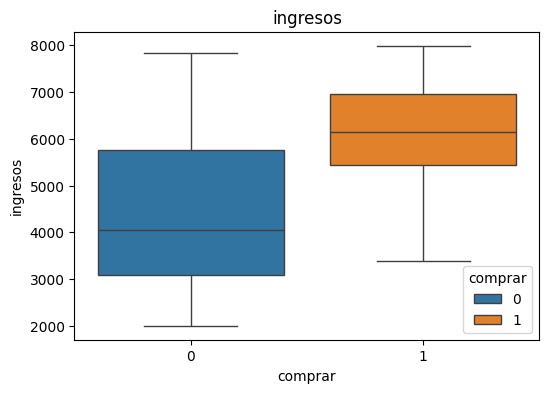

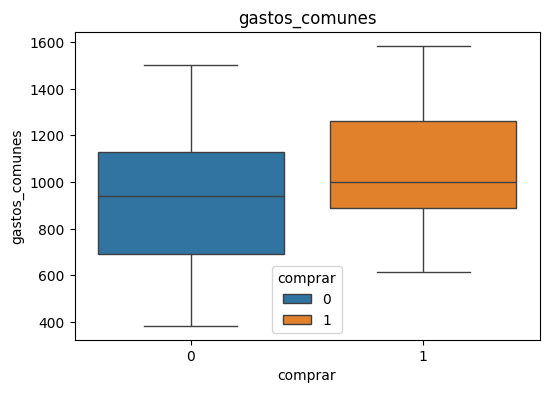

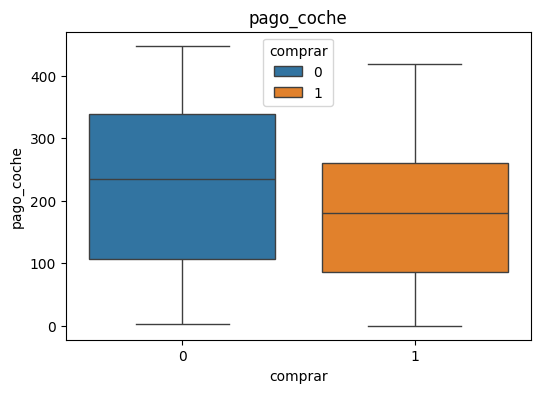

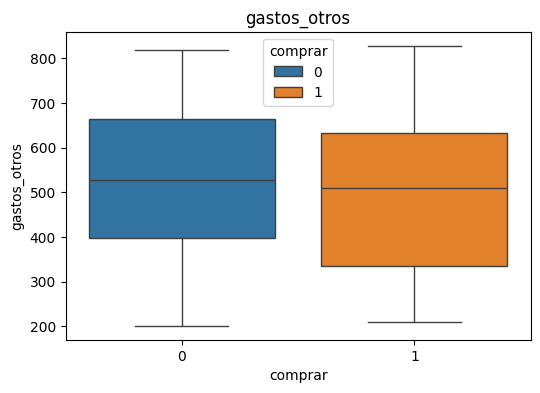

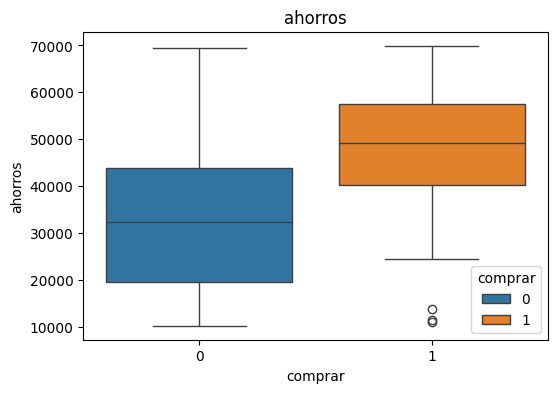

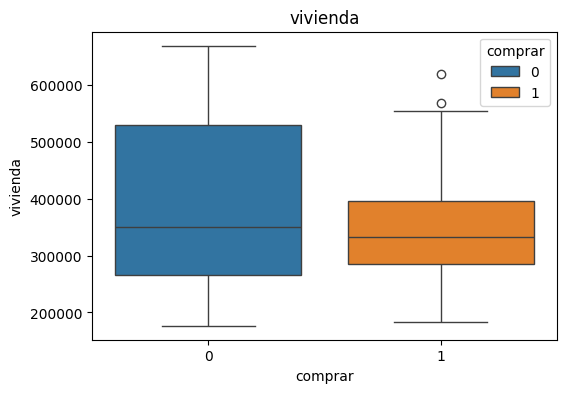

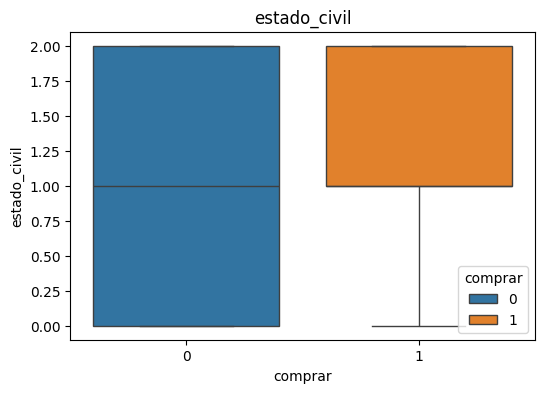

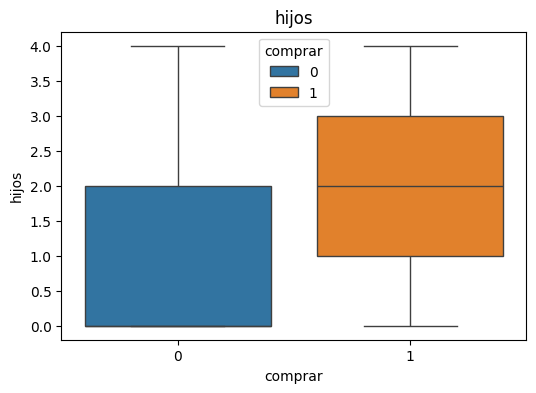

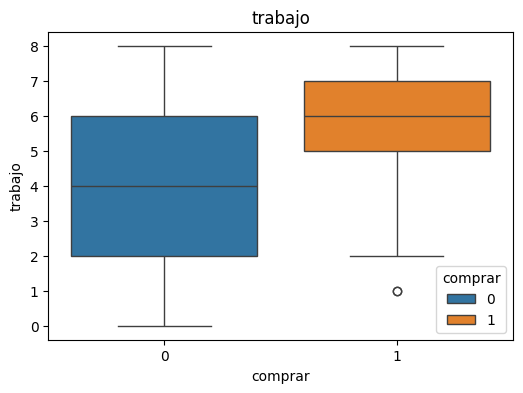

In [16]:
cols = [c for c in us_rent.columns if c != 'comprar']

for col in cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='comprar', y=col, data=us_rent, hue='comprar') # color por target
    plt.title(col)
    plt.show();

## Estandariza los datos
Como el objetivo de estos primeros apartados no es encontrar el mejor modelo con el mejor accuracy, por sencillez, no es necesario dividir en train y test.

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
usr_std = scaler.fit_transform(us_rent.drop(columns='comprar',axis=1))

## Aplicamos PCA
Aplica el algoritmo de PCA para 9 components, es decir, para todas las features

In [22]:
from sklearn.decomposition import PCA

pca = PCA()
usr_pca = pca.fit_transform(usr_std)

df_pca = pd.DataFrame(
    usr_pca,
    columns=[f'PC{i+1}' for i in range(usr_pca.shape[1])]
)

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
0,1.321915,-0.222950,1.599863,-0.885014,0.646617,-0.700208,0.318031,-0.751809,0.269984
1,1.147878,1.716967,0.395722,-0.447960,-0.687805,-0.231969,1.542487,0.221799,0.438425
2,0.090369,1.836066,1.359382,0.337505,0.742387,0.593030,-1.540495,0.668120,0.153463
3,3.455898,-0.078279,-0.202382,-1.573584,-0.068551,-0.051945,0.909409,0.684486,-0.129045
4,0.916933,-1.184676,0.190036,0.117804,-0.147753,-0.619750,-0.450419,0.194341,0.687452


### Veamos cómo de buenos predictores son las nuevas dimensiones
Responde a las siguientes preguntas:
1. ¿Cuánta varianza explica cada Principal Component?
2. ¿Y de manera acumulada empezando por el PC1?
3. ¿Cuánta varianza explicarían sólo 5 componentes?

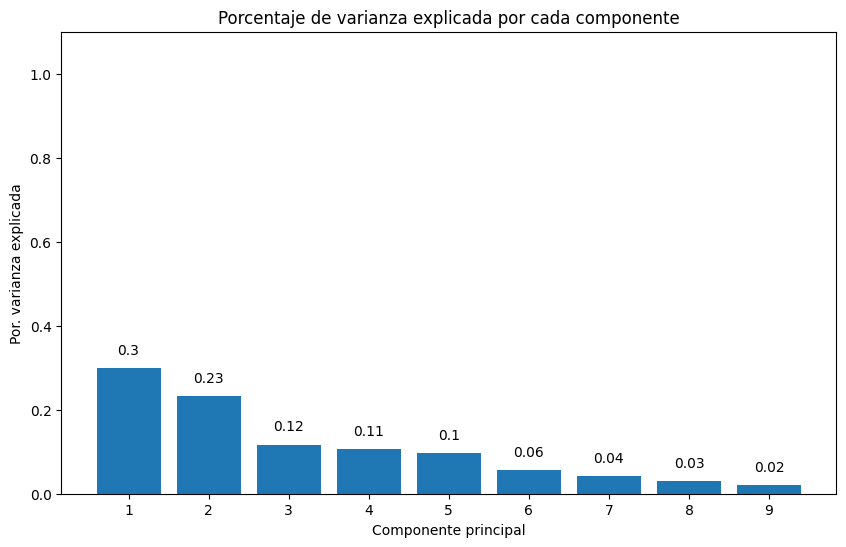

In [ ]:
# 1
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(10, 6))
ax.bar(
    x      = np.arange(pca.n_components_) + 1,
    height = pca.explained_variance_ratio_
)

for x, y in zip(np.arange(len(df_pca.columns)) + 1, pca.explained_variance_ratio_):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_xticks(np.arange(pca.n_components_) + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Porcentaje de varianza explicada por cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada');

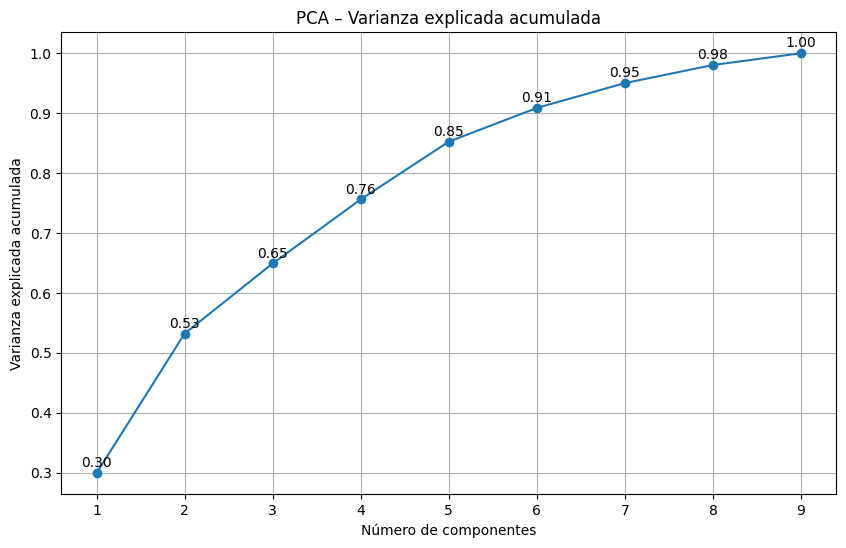

In [24]:
# 2
# Varianza explicada acumulada
var_acum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')

# Añadir etiquetas encima de cada punto
for i, v in enumerate(var_acum):
    plt.text(i + 1, v + 0.01, f"{v:.2f}", ha='center')

plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA – Varianza explicada acumulada')
plt.grid(True)
plt.show();

3. Para 5 componenetes obtenemos un 85% de la varianza total.

### Graficamos la variacion explicada acumulada
Representa en un diagrama de lineas la evolución de la varianza acumulada en función de los PC

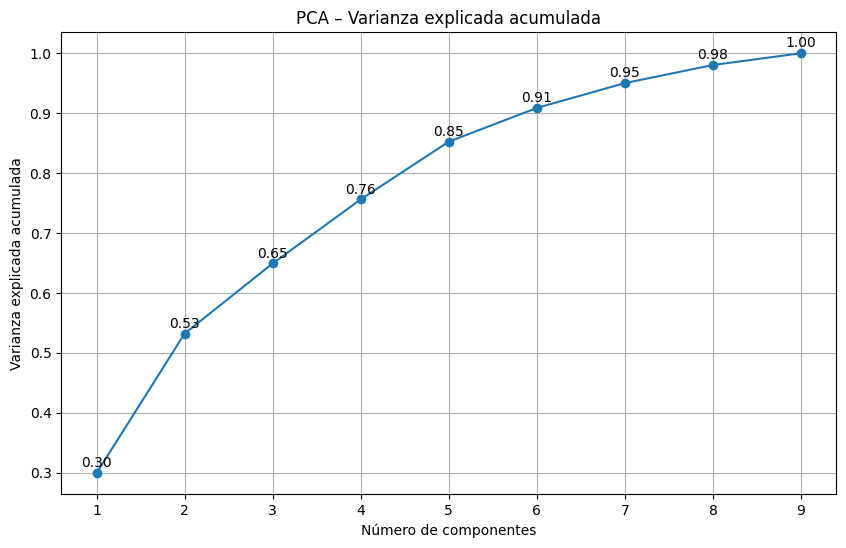

In [25]:
# Varianza explicada acumulada
var_acum = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(var_acum) + 1), var_acum, marker='o')

# Añadir etiquetas encima de cada punto
for i, v in enumerate(var_acum):
    plt.text(i + 1, v + 0.01, f"{v:.2f}", ha='center')

plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('PCA – Varianza explicada acumulada')
plt.grid(True)
plt.show();

### Veamos la correlación entre las nuevas componentes y las dimensiones originales
Representa en un mapa de calor los PCA vs las variables originales. Esta información la puedes obtener del atributo de PCA *components_*.

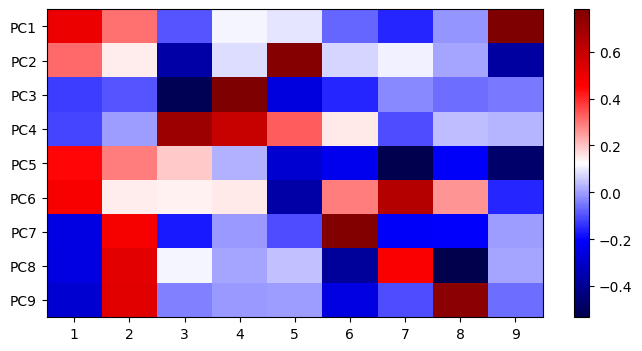

In [26]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 4))
componentes = pca.components_
plt.imshow(componentes.T, cmap='seismic', aspect='auto')
plt.yticks(range(len(df_pca.columns)), df_pca.columns)
plt.xticks(range(len(df_pca.columns)), np.arange(pca.n_components_) + 1)
plt.grid(False)
plt.colorbar();

## Predicciones
1. Divide en train y test
2. Prepara un pipeline compuesto por:
    - StandardScaler,
    - PCA de 5 componentes
    - Un clasificador
3. Entrena
4. Predice con test
5. Calcula el accuracy score en train y test
6. Representa la matriz de confusión
7. ¿Qué combinación de parámetros y componentes mejoraría el accuracy en test?
8. Vuelve a iterar de nuevo con un gridsearch
9. Guarda tu mejor modelo

In [31]:
# 1
from sklearn.model_selection import train_test_split

X = us_rent.drop(columns='comprar',axis=1)
y = us_rent['comprar']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(161, 9)
(41, 9)
(161,)
(41,)


In [32]:
# 2
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

pca_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('clf', RandomForestClassifier(n_estimators=300,
    max_features=4,
    min_samples_split=10,
    max_depth=4))
])

In [33]:
# 3
pca_pipe.fit(X_train, y_train)

modelo_pca = pca_pipe['pca']

In [34]:
# 4
y_pred = pca_pipe.predict(X_test)

In [ ]:
# 5
from sklearn.metrics import accuracy_score

y_pred_train = pca_pipe.predict(X_train)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred)

print("Accuracy train:", acc_train)
print("Accuracy test:", acc_test)

Accuracy train: 0.9130434782608695
Accuracy test: 0.7560975609756098


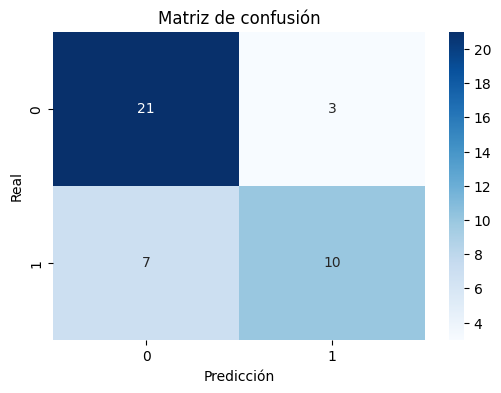

In [ ]:
# 6
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión")
plt.show();

7

En RandomForest, los hiperparámetros que más impacto tienen:

- 'n_estimators'
- 'max_depth'
- 'min_samples_split'
- 'min_samples_leaf'
- 'max_features'

En PCA, el número de componentes también afecta 'n_components'

Así que vamos a buscar combinaciones de:

PCA con 3, 5, 7, 10 componentes y RandomForest con varios hiperparámetros

In [39]:
# 8
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier

pipe_search = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA()),
    ('rf', RandomForestClassifier())
])

param_grid = {
    'pca__n_components': [3, 5, 7, 9],
    'rf__n_estimators': [100, 200, 400],
    'rf__max_depth': [5, 10, 20],
    'rf__min_samples_split': [3, 5, 10],
    'rf__min_samples_leaf': [1, 2, 4],
    'rf__max_features': ['sqrt', 'log2']
}

search_grid = GridSearchCV(
    estimator=pipe_search,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

search_grid.fit(X_train, y_train)

Fitting 5 folds for each of 648 candidates, totalling 3240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...lassifier())])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'pca__n_components': [3, 5, ...], 'rf__max_depth': [5, 10, ...], 'rf__max_features': ['sqrt', 'log2'], 'rf__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time

In [40]:
print(search_grid.best_score_)
print(search_grid.best_params_)
print(search_grid.best_estimator_)

0.8755681818181819
{'pca__n_components': 9, 'rf__max_depth': 10, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 1, 'rf__min_samples_split': 10, 'rf__n_estimators': 100}
Pipeline(steps=[('scaler', StandardScaler()), ('pca', PCA(n_components=9)),
                ('rf',
                 RandomForestClassifier(max_depth=10, min_samples_split=10))])


In [45]:
# 9
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

pipe_final = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=9)),
    ('clf', RandomForestClassifier(n_estimators=100,
    max_features='sqrt',
    min_samples_split=10,
    max_depth=10))
])

pca_pipe.fit(X_train, y_train)

pca_final = pca_pipe['pca']


y_pred_train = pca_pipe.predict(X_train)
y_pred = pca_pipe.predict(X_test)

acc_train = accuracy_score(y_train, y_pred_train)
acc_test = accuracy_score(y_test, y_pred)

print("Accuracy train:", acc_train)
print("Accuracy test:", acc_test)

Accuracy train: 0.9130434782608695
Accuracy test: 0.7560975609756098
